# Exploratory Data Analysis on NBA Team Advanced Stats with Python
## By Gabriel Cuadra

# Overview: 
1. **Importing Libraries and data**
 - numpy
 - pandas
 - matplotlib
 - seaborn
 - plotly
 - CSV file of data
2. **Evaluating initial conditions of data**
 - Dataset shape
 - Basic info
 - Finding irrelevant information to omit
3. **Cleaning data**
 - Omitting irrelevant columns
 - Dropping null values
 - Specifying needed rows
4. **Reevaluating conditions of data**
 - New shape
 - New info
 - etc. 
5. **Analyzing and visualizing cleaned data** 
 - Identifying 5 questions to answer about the data
 - Creating multiple visualizations to answer each question
6. **Conclusions and reflections**
 - What did we find
 - What could've been improved upon

### 1. Importing libraries and Data

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [6]:
df = pd.read_csv("Team_Summaries.csv")

### 2. Evaluating initial conditions of data

#### Dataset Shape

In [7]:
df.shape

(1907, 31)

#### Dataset info

In [120]:
df.info

<bound method DataFrame.info of       season   lg                     team abbreviation  playoffs   age     w  \
0       2026  NBA            Atlanta Hawks          ATL     False  24.7  13.0   
1       2026  NBA           Boston Celtics          BOS     False  26.9  11.0   
2       2026  NBA            Brooklyn Nets          BRK     False  24.2   3.0   
3       2026  NBA            Chicago Bulls          CHI     False  25.8   9.0   
4       2026  NBA        Charlotte Hornets          CHO     False  24.2   6.0   
...      ...  ...                      ...          ...       ...   ...   ...   
1902    1947  BAA  Providence Steamrollers          PRO     False   NaN  28.0   
1903    1947  BAA        St. Louis Bombers          STB      True   NaN  38.0   
1904    1947  BAA          Toronto Huskies          TRH     False   NaN  22.0   
1905    1947  BAA      Washington Capitols          WSC      True   NaN  49.0   
1906    1947  BAA           League Average          NaN     False   NaN   NaN

#### Dataset columns

In [121]:
df.columns

Index(['season', 'lg', 'team', 'abbreviation', 'playoffs', 'age', 'w', 'l',
       'pw', 'pl', 'mov', 'sos', 'srs', 'o_rtg', 'd_rtg', 'n_rtg', 'pace',
       'f_tr', 'x3p_ar', 'ts_percent', 'e_fg_percent', 'tov_percent',
       'orb_percent', 'ft_fga', 'opp_e_fg_percent', 'opp_tov_percent',
       'drb_percent', 'opp_ft_fga', 'arena', 'attend', 'attend_g'],
      dtype='object')

### 3. Cleaning data

In [8]:
nba = df.drop(['lg','pw','pl','arena','attend','attend_g'],axis = 1)
nba = nba[nba['season'] > 1976]
nba = nba[nba['team'] != 'League Average']

##### Notes: 
 - removed unnecessary columns such as arena, attendance, projected wins/losses
 - removed all teams before the ABA/NBA merger
 - removed the 'League Average' rows automatically created

# 4. Reevaluating conditions of new data

#### New dataset shape

In [9]:
nba.shape

(1380, 25)

#### New dataset head

In [10]:
nba.head()

,season,team,abbreviation,playoffs,age,w,l,mov,sos,srs,...,x3p_ar,ts_percent,e_fg_percent,tov_percent,orb_percent,ft_fga,opp_e_fg_percent,opp_tov_percent,drb_percent,opp_ft_fga
0,2026,Atlanta Hawks,ATL,False,24.7,13.0,8.0,2.33,-0.91,1.43,...,0.417,0.598,0.565,13.3,23.0,0.204,0.537,14.2,72.4,0.224
1,2026,Boston Celtics,BOS,False,26.9,11.0,9.0,4.00,-0.05,3.95,...,0.468,0.573,0.545,10.5,29.4,0.162,0.523,13.2,71.1,0.252
2,2026,Brooklyn Nets,BRK,False,24.2,3.0,16.0,-10.89,1.69,-9.21,...,0.485,0.564,0.521,13.8,24.9,0.238,0.583,12.4,72.0,0.218
3,2026,Chicago Bulls,CHI,False,25.8,9.0,10.0,-3.11,-0.09,-3.19,...,0.424,0.588,0.552,12.9,22.9,0.209,0.537,10.5,74.0,0.211
4,2026,Charlotte Hornets,CHO,False,24.2,6.0,14.0,-4.30,-0.54,-4.84,...,0.454,0.577,0.532,13.6,28.8,0.232,0.576,11.7,76.4,0.181


#### New dataset info

In [12]:
nba.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1380 entries, 0 to 1428
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   season            1380 non-null   int64  
 1   team              1380 non-null   object 
 2   abbreviation      1380 non-null   object 
 3   playoffs          1380 non-null   bool   
 4   age               1380 non-null   float64
 5   w                 1380 non-null   float64
 6   l                 1380 non-null   float64
 7   mov               1380 non-null   float64
 8   sos               1380 non-null   float64
 9   srs               1380 non-null   float64
 10  o_rtg             1380 non-null   float64
 11  d_rtg             1380 non-null   float64
 12  n_rtg             1380 non-null   float64
 13  pace              1380 non-null   float64
 14  f_tr              1380 non-null   float64
 15  x3p_ar            1314 non-null   float64
 16  ts_percent        1380 non-null   float64
 17  

#### New dataset description

In [128]:
nba.describe()

,season,age,w,l,mov,sos,srs,o_rtg,d_rtg,n_rtg,...,x3p_ar,ts_percent,e_fg_percent,tov_percent,orb_percent,ft_fga,opp_e_fg_percent,opp_tov_percent,drb_percent,opp_ft_fga
count,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,...,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000
mean,2004.146119,26.772755,39.510654,39.510654,-0.003151,-0.000342,-0.003387,107.656088,107.647412,0.008676,...,0.206664,0.541686,0.499458,13.785616,28.272527,0.227447,0.499372,13.784170,71.709665,0.227550
std,13.260066,1.680823,13.365913,13.325738,4.757364,0.435825,4.576459,4.628204,4.373602,4.940399,...,0.124107,0.024753,0.027529,1.313466,4.336724,0.030903,0.026218,1.388356,4.019532,0.032094
min,1980.000000,22.100000,2.000000,1.000000,-15.200000,-3.330000,-14.680000,92.200000,94.100000,-15.200000,...,0.011000,0.468000,0.424000,9.900000,17.900000,0.143000,0.423000,10.300000,61.500000,0.145000
25%,1993.000000,25.600000,30.000000,30.000000,-3.177500,-0.290000,-3.127500,104.600000,104.625000,-3.375000,...,0.108000,0.524000,0.480000,12.900000,24.900000,0.204000,0.481000,12.900000,68.400000,0.204000
50%,2005.000000,26.600000,41.000000,39.000000,0.345000,-0.005000,0.270000,107.200000,107.500000,0.300000,...,0.200500,0.539000,0.496000,13.700000,28.300000,0.226000,0.497000,13.700000,71.800000,0.225000
75%,2016.000000,27.900000,50.000000,49.000000,3.435000,0.290000,3.247500,110.700000,110.400000,3.500000,...,0.291000,0.557000,0.516000,14.600000,31.500000,0.249000,0.514000,14.700000,74.800000,0.250000
max,2026.000000,32.000000,73.000000,72.000000,15.480000,2.930000,12.700000,125.700000,123.600000,15.200000,...,0.536000,0.629000,0.587000,18.700000,39.100000,0.334000,0.585000,19.000000,81.600000,0.347000


#### New dataset columns

In [14]:
nba.columns

Index(['season', 'team', 'abbreviation', 'playoffs', 'age', 'w', 'l', 'mov',
       'sos', 'srs', 'o_rtg', 'd_rtg', 'n_rtg', 'pace', 'f_tr', 'x3p_ar',
       'ts_percent', 'e_fg_percent', 'tov_percent', 'orb_percent', 'ft_fga',
       'opp_e_fg_percent', 'opp_tov_percent', 'drb_percent', 'opp_ft_fga'],
      dtype='object')

#### Checking for null values

In [15]:
nba.isna().sum()

season               0
team                 0
abbreviation         0
playoffs             0
age                  0
w                    0
l                    0
mov                  0
sos                  0
srs                  0
o_rtg                0
d_rtg                0
n_rtg                0
pace                 0
f_tr                 0
x3p_ar              66
ts_percent           0
e_fg_percent         0
tov_percent          0
orb_percent          0
ft_fga               0
opp_e_fg_percent     0
opp_tov_percent      0
drb_percent          0
opp_ft_fga           0
dtype: int64

##### Notes: 
Null values are only found in the 3 point attempt rate column. This is because the three point line wasn't added until the early 1980s.   

#### Dropping null values

In [16]:
nba.dropna(subset = 'x3p_ar', inplace=True)

#### Reevaluating null counts

In [17]:
print(nba.isna().sum())

season              0
team                0
abbreviation        0
playoffs            0
age                 0
w                   0
l                   0
mov                 0
sos                 0
srs                 0
o_rtg               0
d_rtg               0
n_rtg               0
pace                0
f_tr                0
x3p_ar              0
ts_percent          0
e_fg_percent        0
tov_percent         0
orb_percent         0
ft_fga              0
opp_e_fg_percent    0
opp_tov_percent     0
drb_percent         0
opp_ft_fga          0
dtype: int64


##### Notes:
Data now starts from 1980 instead of 1977.

# 5. Now that the data cleaning is done, let's analyze and visualze the data. 

## Question 1. What advanced stat is the most correlated with winning

#### Creating heatmap of dataset

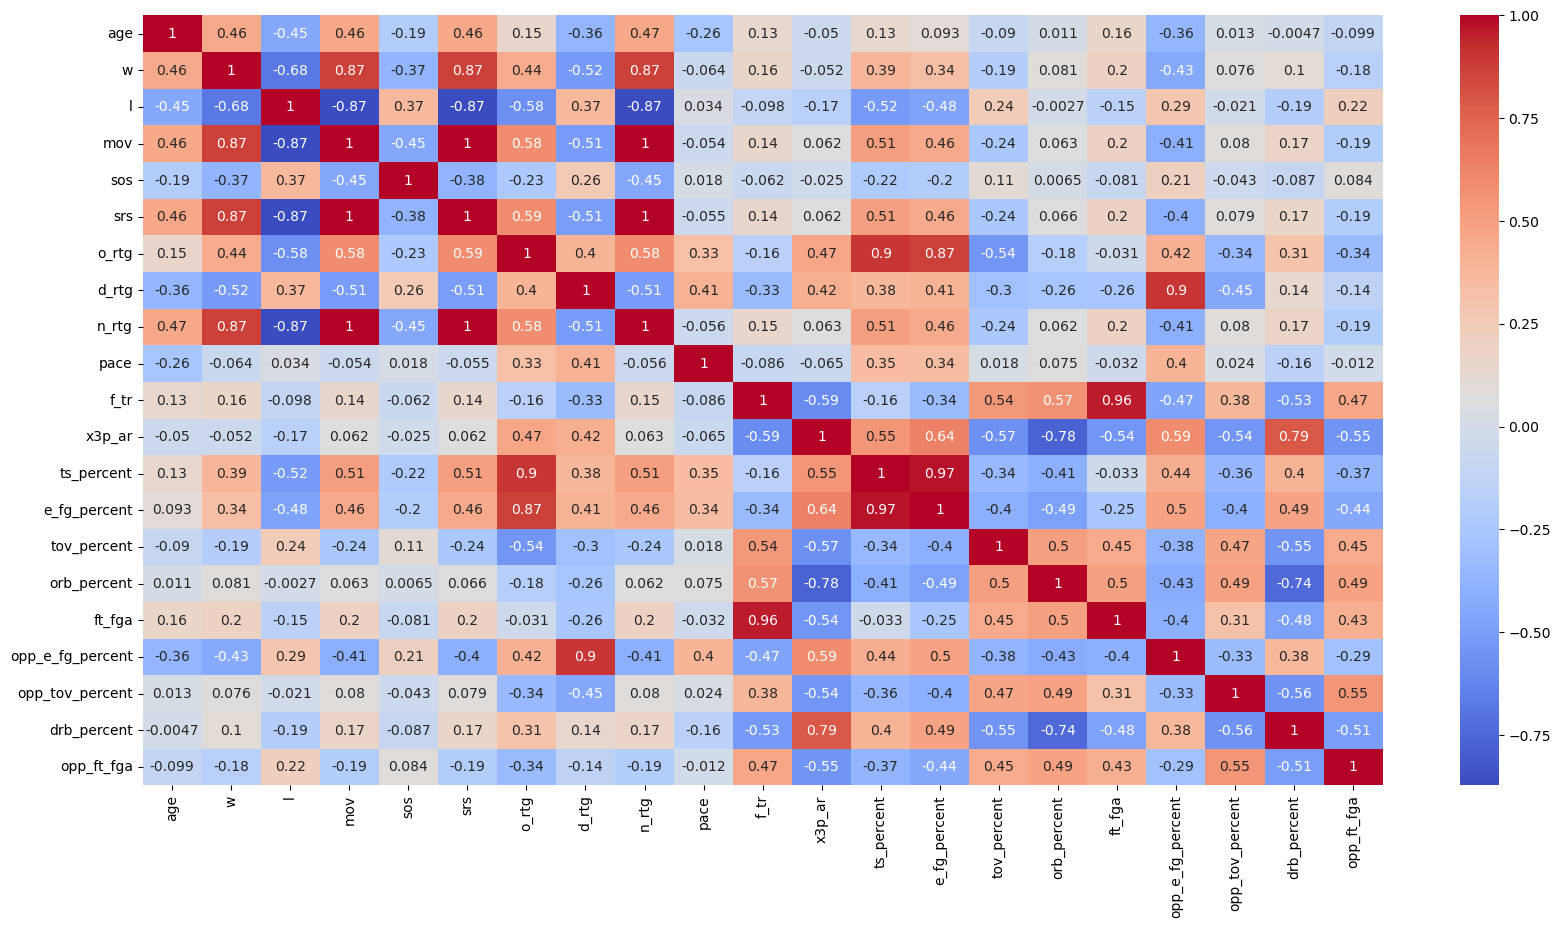

In [144]:
nba_num = nba.select_dtypes(include='number')
nba_num = nba_num.drop(['season'],axis=1)
corr = nba_num.corr()
plt.figure(figsize = (20,10))
sns.heatmap(corr, annot = True, cmap= 'coolwarm')
plt.savefig("my_plot.png")

#### Finding the correlation for only the win column. Then visualizing the correlations.

n_rtg               0.873326
mov                 0.872143
srs                 0.871565
age                 0.456455
o_rtg               0.443546
ts_percent          0.386239
e_fg_percent        0.339117
ft_fga              0.197857
f_tr                0.160286
drb_percent         0.101934
orb_percent         0.081133
opp_tov_percent     0.075524
x3p_ar             -0.052106
pace               -0.064280
opp_ft_fga         -0.177393
tov_percent        -0.186054
sos                -0.369199
opp_e_fg_percent   -0.434040
d_rtg              -0.517139
Name: w, dtype: float64


<Axes: title={'center': 'Win correlations'}>

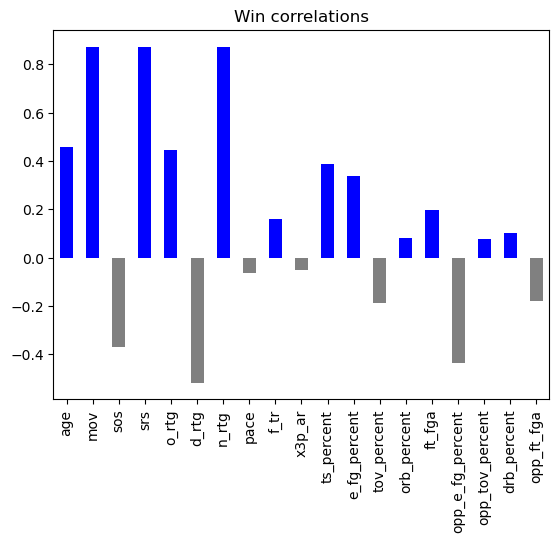

In [19]:
corr_w = corr['w']
corr_w = corr_w.drop(['w','l'])
print(corr_w.sort_values(ascending = False))
colors1 = ['blue' if val >= 0 else 'grey' for val in corr_w] 
corr_w.plot.bar(title = 'Win correlations', color = colors1 )

 ### Key findings: 

    Margin of victory, simple rating system, and net rating are the most correlated with team wins. (also technically defensive rating since it is scored inversely)


## Question 2. How did the frequency of three-point shot attempts change over time? 

#### Grouping the data by year and finding the average 3 point shot rate

In [20]:
nba3s = nba[["season", "x3p_ar"]].groupby("season").mean()
nba3s.head()

,x3p_ar
season,
1980,0.030636
1981,0.022913
1982,0.025870
1983,0.025130
1984,0.026870


#### Visualizing how the 3 point rate changed over time

Text(0.5, 0, 'Season')

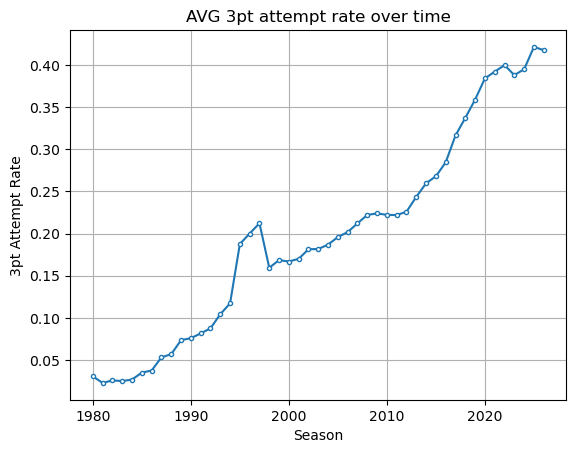

In [132]:

nba3s.plot(marker = '.',markersize = 6, markerfacecolor='white', linestyle = '-',legend=False)
plt.title('AVG 3pt attempt rate over time')
plt.grid(True)
plt.ylabel('3pt Attempt Rate')
plt.xlabel('Season')

##### Notes:
- Steady increase over time
- Hit peak in 2025
- Biggest spike in mid 1990s


#### Finding top 10 highest frequency 3 pt years 

In [22]:
highsort3s = nba3s.sort_values(by='x3p_ar', ascending = False)
highsort3s.iloc[:10,:]

,x3p_ar
season,
2025,0.421200
2026,0.417367
2022,0.399633
2024,0.394700
2021,0.391867
2023,0.387800
2020,0.383900
2019,0.358767
2018,0.337033


#### Visualizing top 10 3 point rate years

Text(0.5, 1.0, 'Top 10 highest 3pt Volume seasons')

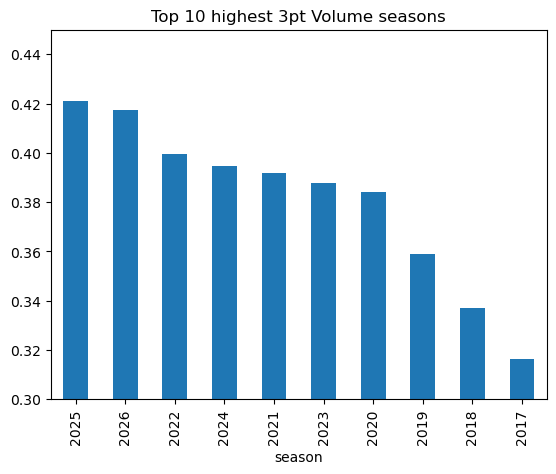

In [65]:
top10_3pt = highsort3s.iloc[:10,:]

top10_3pt.plot.bar(legend=False)
plt.ylim(0.3, 0.45)
plt.title("Top 10 highest 3pt Volume seasons")


##### Notes:
Seems to be the most recent seasons available


#### 10 Lowest 3pt rate years

In [24]:
lowsort3s = nba3s.sort_values(by='x3p_ar')
lowsort3s.iloc[:10,:]

,x3p_ar
season,
1981,0.022913
1983,0.025130
1982,0.025870
1984,0.026870
1980,0.030636
1985,0.035174
1986,0.037609
1987,0.053217
1988,0.057000


#### Visualizing 10 lowest 3 point volume years

Text(0, 0.5, '3Pt Attempt Rate')

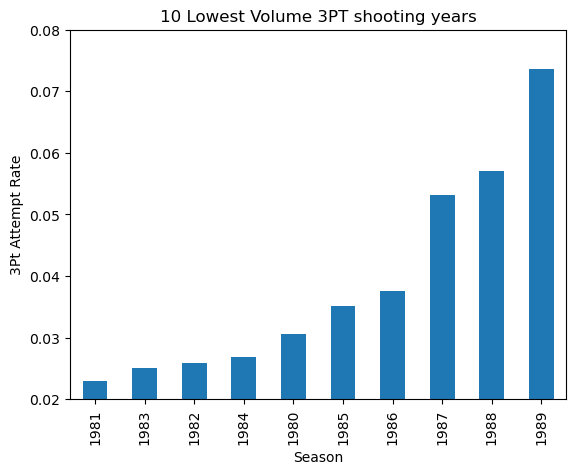

In [67]:
bottom10_3pt = lowsort3s.iloc[:10,:]

bottom10_3pt.plot.bar(legend=False)
plt.ylim(0.02, 0.08)
plt.title("10 Lowest Volume 3PT shooting years")
plt.xlabel("Season")
plt.ylabel("3Pt Attempt Rate")

##### Notes:
The opposite of the top 10 years. Looks to be the oldest seasons available. 

## Question 3. What is more important? Offense or Defense?

##### Notes: Must compare by absolute value since defensive rating is measured inversely

#### Finding correlation with Offensive and Defensive rating on team success metrics

In [26]:
corr_d_o = corr[['o_rtg', 'd_rtg']].abs()
corr_d_o = corr_d_o.loc[['mov','srs','n_rtg','w']]
corr_d_o

,o_rtg,d_rtg
mov,0.584309,0.509863
srs,0.585275,0.505277
n_rtg,0.583845,0.511763
w,0.443546,0.517139


#### Visualizing correlation with Offensive and Defensive rating on team success metrics

([<matplotlib.axis.XTick at 0x12737dc70>,
 [Text(0, 0, 'Margin of Victory'),
  Text(1, 0, 'Simple Rating'),
  Text(2, 0, 'Net Rating'),
  Text(3, 0, 'Wins')])

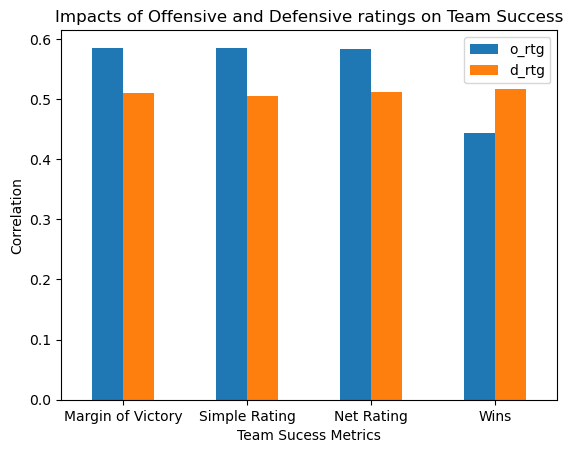

In [27]:
corr_d_o.plot.bar()
plt.title("Impacts of Offensive and Defensive ratings on Team Success")
plt.xlabel("Team Sucess Metrics")
plt.ylabel("Correlation")
plt.xticks([0,1,2,3],['Margin of Victory','Simple Rating','Net Rating','Wins'],rotation='horizontal')

##### Notes: Offensive seems to have more impact so far

#### Caluclating Overall impact: 

In [28]:
o_d_avg = corr_d_o.mean()
o_d_avg
    

o_rtg    0.549244
d_rtg    0.511011
dtype: float64

##### Notes: overall impact calculated through means of correlations

#### Visualizing overall impact

Text(0, 0.5, 'Avg Correlation on Success Metrics')

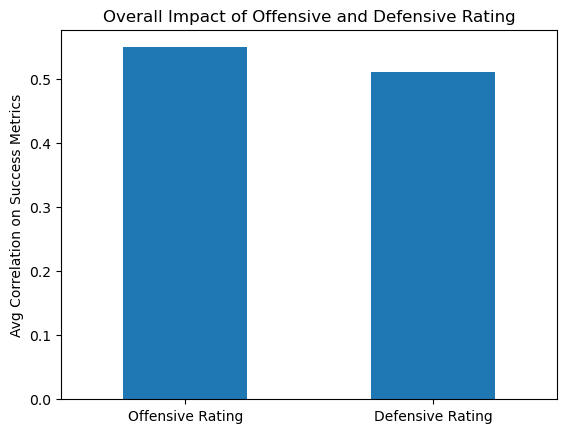

In [29]:
o_d_avg.plot.bar()
plt.title('Overall Impact of Offensive and Defensive Rating')
plt.xticks([0,1],['Offensive Rating','Defensive Rating'],rotation='horizontal')
plt.ylabel('Avg Correlation on Success Metrics')

##### Notes: Seems offense has slightly more impact

## Question 4. How has pace changed over the years? 

#### Grouping by season and finding average team pace

In [30]:
nba_pace = nba[["season", "pace"]].groupby("season").mean()
nba_pace.head()

,pace
season,
1980,103.072727
1981,101.826087
1982,100.873913
1983,103.056522
1984,101.426087


#### Visualizing pace over time

Text(0.5, 0, 'Season')

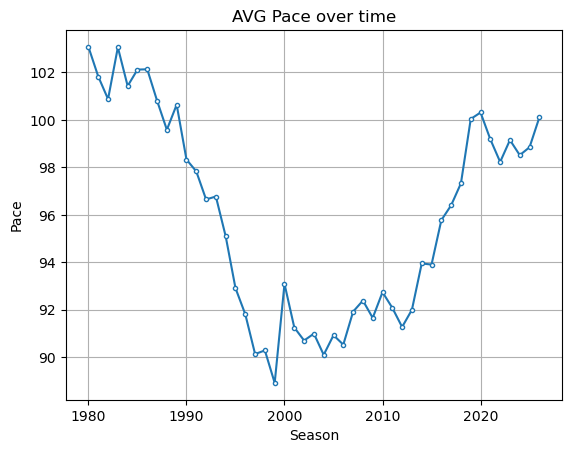

In [31]:
nba_pace.plot(marker = '.',markersize = 6, markerfacecolor='white', linestyle = '-',legend=False)
plt.title('AVG Pace over time')
plt.grid(True)
plt.ylabel('Pace')
plt.xlabel('Season')

#### Notes:
- Peak in pace in the 1980s
- STEEP decline starting in 1989 all the way until 1999
- Plateaus in 2000s
- Starts to climb in 2010s

This correlates with the NBA rule changes made in the 1990s to make certain defenses illegal and emphasize slower 1 on 1 offensive schemes.
The rise in the 2010s could be attributed to the 3 point revolutions started by the Golden State Warriors. 

### Comparing rise in pace to rise in 3pt shooting in modern era through scatter plot


Text(0.5, 1.0, '3PT Attempt rate Vs. Pace( Modern Era : 1999-2026 )')

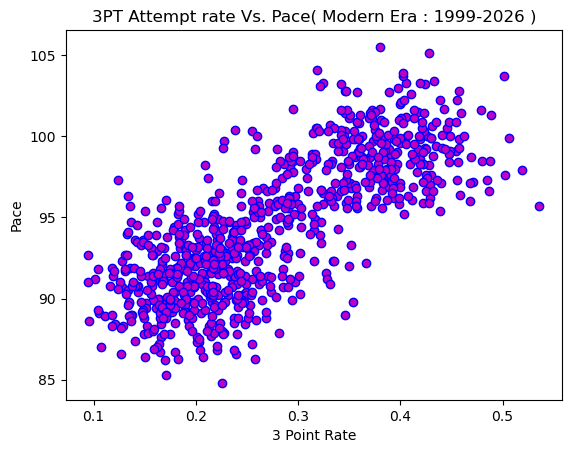

In [137]:
nba_modern = nba.query('season >= 1999')
nba_modern_3 = nba_modern['x3p_ar'] 
nba_modern_pace = nba_modern['pace']
plt.scatter(nba_modern_3, nba_modern_pace, marker = 'o', c='m',edgecolor='blue')
plt.ylabel('Pace')
plt.xlabel('3 Point Rate')
plt.title('3PT Attempt rate Vs. Pace( Modern Era : 1999-2026 )')

##### Notes: Clear correlations with 3 point rate and pace

#### Interactive scatter plot to highlight all teams

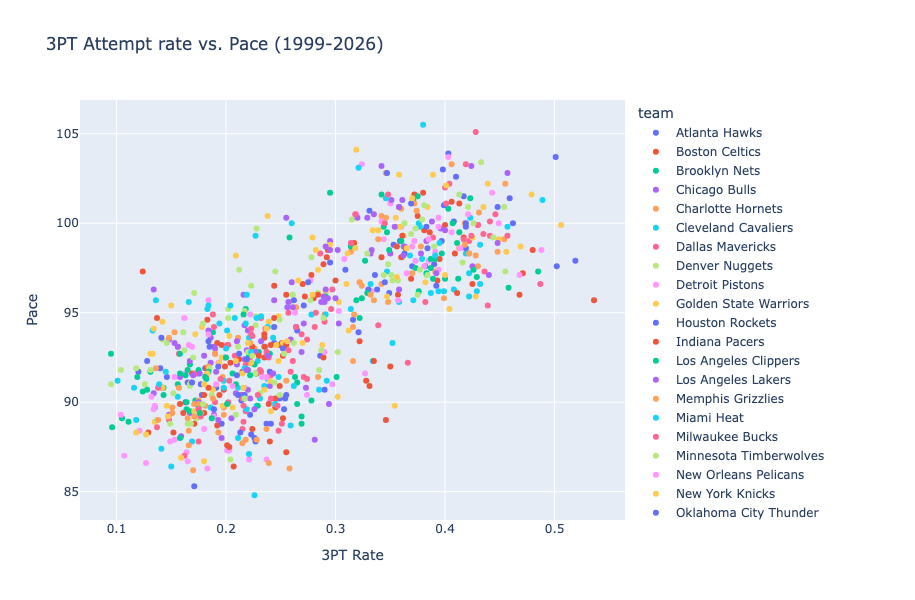

In [64]:
nba_modern = nba_modern.copy()
nba_modern['team_and_year'] = nba_modern['season'].astype(str) + ' ' + nba_modern['team']
pace_3p_fig = px.scatter(nba_modern, 
                 x="x3p_ar", 
                 y="pace", 
                 color="team",
                 hover_name="team_and_year",
                 title="3PT Attempt rate vs. Pace (1999-2026)")
pace_3p_fig.update_layout(autosize = False, width = 600, height = 600,xaxis_title="3PT Rate", yaxis_title="Pace",xaxis=dict(nticks=8,))

pace_3p_fig.show() 

##### Notes: There still seems to be clear correlation, and the highest paced team from the time frame is this year's miami heat. The lowest paced team is the 1999 Miami Heat. 

## Question 5: Who are the best and worst teams of all time

#### Creating new metric called "overall_rating" to evaluate the best and worst teams of all time

In [90]:
nba['team_and_year'] = nba['season'].astype(str) + ' ' + nba['team']
nba_ovr = nba[['season','team_and_year','w','mov','srs','n_rtg']]
nba_ovr = nba_ovr.copy()
nba_ovr = nba_ovr[nba_ovr['season'] != 2026]
nba_ovr = nba_ovr.drop(['season'],axis = 1)
nba_ovr['ovr_rating'] = (nba_ovr['w'] + nba_ovr['mov'] + nba_ovr['srs'] + nba_ovr['n_rtg'])
nba_ovr.sort_values(by = 'ovr_rating', ascending = False)

,team_and_year,w,mov,srs,n_rtg,ovr_rating
925,1996 Chicago Bulls,72.0,12.24,11.80,13.4,109.44
51,2025 Oklahoma City Thunder,68.0,12.87,12.70,12.8,106.37
319,2016 Golden State Warriors,73.0,10.76,10.38,10.7,104.84
895,1997 Chicago Bulls,69.0,10.80,10.70,12.0,102.50
288,2017 Golden State Warriors,67.0,11.63,11.35,11.6,101.58
...,...,...,...,...,...,...
332,2016 Philadelphia 76ers,10.0,-10.23,-9.92,-10.4,-20.55
1180,1987 Los Angeles Clippers,12.0,-11.43,-11.00,-11.1,-21.53
868,1998 Denver Nuggets,11.0,-11.78,-11.74,-13.1,-25.62
1013,1993 Dallas Mavericks,11.0,-15.20,-14.68,-15.2,-34.08


##### Notes: 'overall_rating' was created through adding all team success metrics together(wins, margin of victory, simple rating system, and net rating). I was also surprised to see the 2025 Thunder in the top 3. I knew they were a great team but I didn't expect them to be this highly rated through advanced metrics. 

#### Visualizing the top 10 teams

Text(0.5, 0, 'Team and Year')

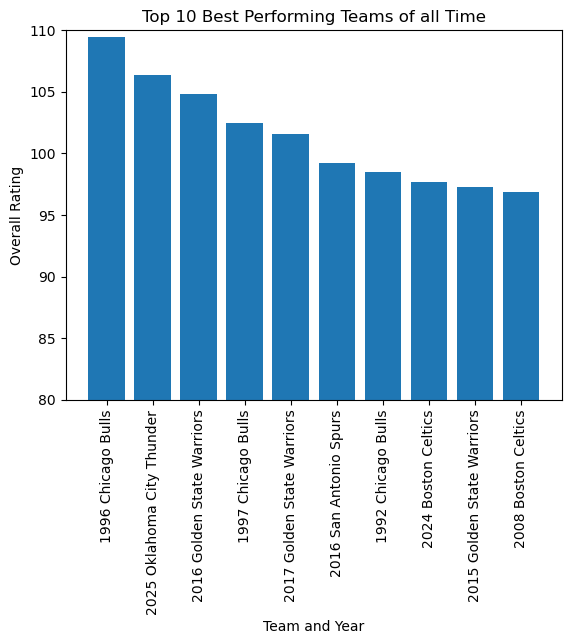

In [118]:
nba_ovr_top = nba_ovr.sort_values(by = 'ovr_rating', ascending = False)
nba_ovr_top10 = nba_ovr_top.iloc[:10,:]
xtop = nba_ovr_top10['team_and_year']
ytop = nba_ovr_top10['ovr_rating']
plt.bar(xtop,ytop)
plt.xticks(rotation = 'vertical')
plt.ylim(80, 110)
plt.title('Top 10 Best Performing Teams of all Time')
plt.ylabel('Overall Rating')
plt.xlabel('Team and Year')

##### Notes: Bulls, Warriors, and Celtics all appear multiple times. I also expect more Thunder teams to appear here as time goes on. Their 2026 team might already be better than their 2025 team based on Shai's improvement. 

#### Bottom 10 performing teams

Text(0.5, 0, 'Team and Year')

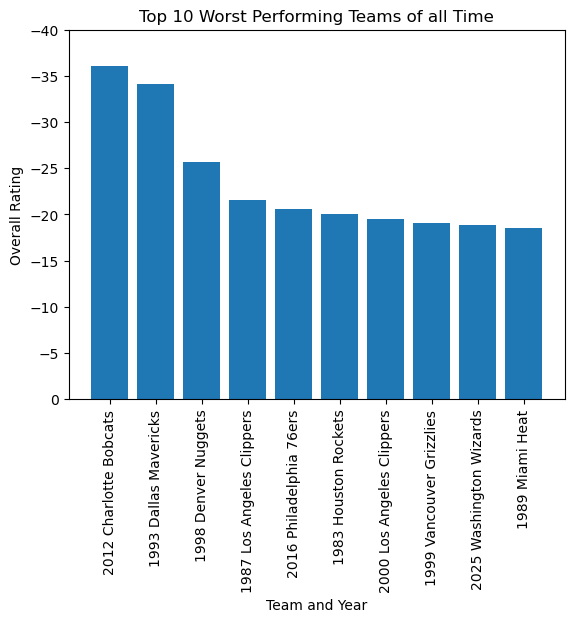

In [117]:
nba_ovr_bot = nba_ovr.sort_values(by = 'ovr_rating')
nba_ovr_bot10 = nba_ovr_bot.iloc[:10,:]
xbot = nba_ovr_bot10['team_and_year']
ybot = nba_ovr_bot10['ovr_rating']
plt.bar(xbot,ybot)
plt.xticks(rotation = 'vertical')
plt.ylim(0, -40)
plt.title('Top 10 Worst Performing Teams of all Time')
plt.ylabel('Overall Rating')
plt.xlabel('Team and Year')

##### Notes: The Clippers are the only franchise to have multiple teams on this list. The 2012 Bobcats are statistically the worst team of all time. 

# 6. Final conclusion and reflection:

Throughout this process of exploratory data analysis, multiple questions were created and promptly answered regarding the NBA advanced statistics dataset. It was concluded that the margin of victory, simple rating system, net rating, and also defensive rating are the most correlated with team wins. It was later found that over time, the leaguewide three-point attempt rate increased steadily, peaking in 2025. This 3 point attempt rate was found to be in significant correlation with leaguewide pace(starting from 1999), serving as a potential answer to why pace has been increasing since the 2000s. Finally, it was concluded that the 1996 Bulls, 2025 Thunder, and 2016 Warriors were the best teams of all time, while the 2012 Bobcats, 1993 Mavericks, and 1998 Nuggets were the worst of all time. 

While the data included years down to the 1940s, they were not utilized due to having a significantly different ruleset and also being before the NBA/ABA merger. If the earlier years were included, perhaps there would be some new highest-performing or lowest-performing teams. Additionally, statistics do not tell the full picture of basketball. They do not fully capture each team's gameplay, each player's playstyle, and each era's rules, so these results should not be taken as absolute fact. These findings serve as a guideline for us to analyze the visual and more intangible aspects of basketball, and we cannot rely on statistics and data alone to get the full picture of basketball, or anything for that matter. 